In [1]:
# DATA CLEANING AND PREPARATION STAGE

import pandas as pd

df = pd.read_csv("Diabetes_Health_Indicators_Dataset_5050Split.csv")

cols_to_convert = [
    "Diabetes_binary", "HighBP", "HighChol", "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "Stroke", "HeartDiseaseorAttack", "GenHlth", "DiffWalk", "Sex", "CholCheck", "AnyHealthcare", "NoDocbcCost"
]
df[cols_to_convert] = df[cols_to_convert].astype("int8")

cols_to_convert_2 = [
    "BMI", "MentHlth", "PhysHlth", "Age", "Education", "Income"
]
df[cols_to_convert_2] = df[cols_to_convert_2].astype("int64")

print("\nNumber of Rows and Columns:", df.shape) # satır ve sütun sayısı
print("\n", df.columns) # Sütunlar
print(df.info()) # Veri seti hakkında özet bilgi

female_count = df["Sex"].value_counts()[0]
print("\nNumber of Females:", female_count)
male_count = df["Sex"].value_counts()[1]
print("Numer of Males:", male_count)


Number of Rows and Columns: (70692, 22)

 Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  int8 
 1   HighBP                70692 non-null  int8 
 2   HighChol              70692 non-null  int8 
 3   CholCheck             70692 non-null  int8 
 4   BMI                   70692 non-null  int64
 5   Smoker                70692 non-null  int8 
 6   Stroke                70692 non-null  int8 
 7   HeartDiseaseorAttack  70692 non-null  int8 
 8   PhysActivity    


Female (0) Average BMI: 29.85
Male (1) Average BMI: 29.86


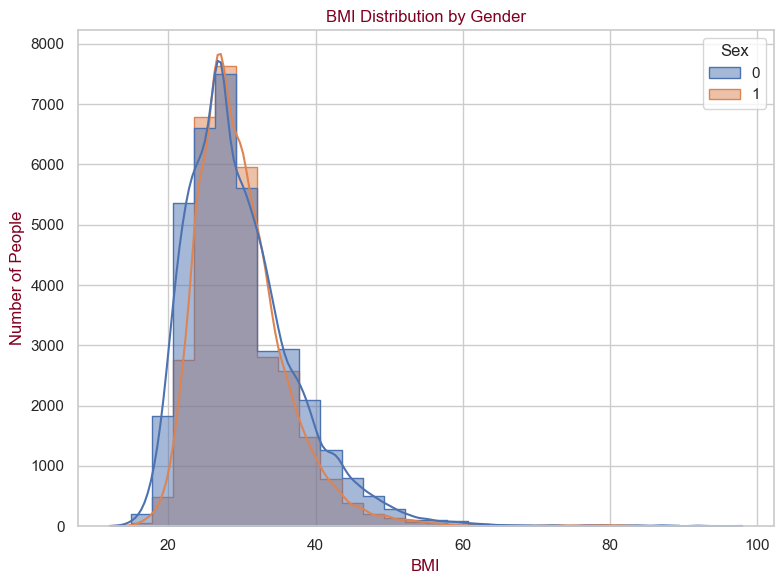

In [2]:
# DISTRIBUTION OF BMI (Body Mass Index)

import matplotlib.pyplot as plt
import seaborn as sns

# Setting Seaborn Theme
sns.set_theme(style="whitegrid", palette="deep")

avg_bmi = df.groupby("Sex")["BMI"].mean()
print(f"\nFemale (0) Average BMI: {avg_bmi[0]:.2f}")
print(f"Male (1) Average BMI: {avg_bmi[1]:.2f}")

# Ploting BMI Distribution
plt.figure(figsize=(8,6))
sns.histplot(
    data=df,
    x="BMI",
    hue="Sex", # aynı grafikte birden fazla çubuğu gösterir. Bu, gruplar arası karşılaştırma yapmak için kullanılır
    kde=True, # Kernel Density Estimate-histogram çubuklarının üzerine, verinin dağılım eğrisini çizer. Bu, dağılımın genel şeklini görmeyi sağlar
    bins=30,
    alpha=0.5, # Çubukların şeffaflık derecesini belirler
    element="step" # Histogramın çizim stilini belirler. step, çubukların içini doldurmak yerine sadece dış çizgilerini çizer
)
plt.title("BMI Distribution by Gender", color='#800020')
plt.xlabel("BMI", color='#800020')
plt.ylabel("Number of People", color='#800020')
plt.tight_layout()


DISTRIBUTION of TENSION by GENDER
|   Sex |   HighBP_Rate | HighBP_Percent   |
|------:|--------------:|:-----------------|
|     0 |      0.544886 | 54.49%           |
|     1 |      0.585526 | 58.55%           |
0 = Female, 1 = Male


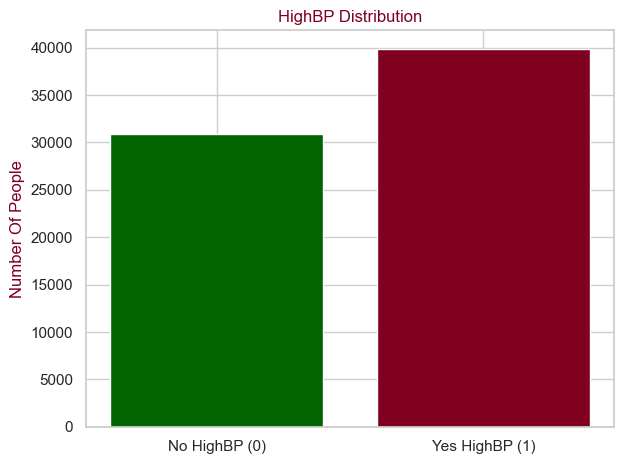

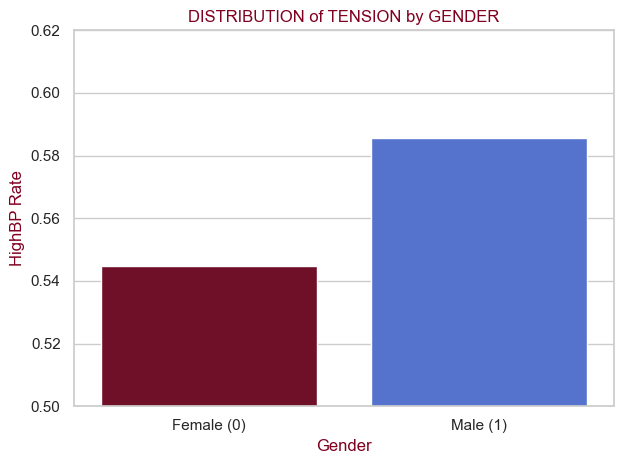

In [3]:
# DISTRIBUTION OF HighBP (Tension)

# Counting HighBP Values
counts = df['HighBP'].value_counts().sort_index()

# Setting Colors of Bars
colors = ['#006400' if val == 0 else '#800020' for val in counts.index]

# Ploting HighBP Distribution
plt.figure()
plt.bar(
    counts.index.astype(str),
    counts.values,
    color=colors
)
plt.xticks(
    [0, 1],
    ['No HighBP (0)', 'Yes HighBP (1)']
)
plt.ylabel('Number Of People', color='#800020')
plt.title('HighBP Distribution', color='#800020')
plt.tight_layout()


# DISTRIBUTION of TENSION by GENDER

highbp_proportions = df.groupby('Sex')['HighBP'].mean().reset_index()
highbp_proportions.columns = ['Sex', 'HighBP_Rate']

# Oranları yüzde formatında yazdırmak için
highbp_proportions['HighBP_Percent'] = (highbp_proportions['HighBP_Rate'] * 100).map('{:.2f}%'.format)

print("\nDISTRIBUTION of TENSION by GENDER")
print(highbp_proportions.to_markdown(index=False))
print("0 = Female, 1 = Male")

custom_palette = {
    0.0: '#800020',
    1.0: '#4169e1'
}

plt.figure()
sns.barplot(
    x='Sex',
    y='HighBP_Rate',
    hue='Sex',
    data=highbp_proportions,
    palette=custom_palette,
    dodge=False,
    legend=False
)

# X ekseni etiketleri
plt.xticks([0, 1], ['Female (0)', 'Male (1)'])

# Y ekseni ölçüsü
plt.ylim(0.5, 0.62)

# Başlık ve eksen renkleri
plt.title('DISTRIBUTION of TENSION by GENDER', color='#800020')
plt.xlabel('Gender', color='#800020')
plt.ylabel('HighBP Rate', color='#800020')
plt.tight_layout()


DISTRIBUTION of CHOLESTROL by GENDER
|   Sex |   HighChol_Rate | HighChol_Percent   |
|------:|----------------:|:-------------------|
|     0 |        0.517767 | 51.78%             |
|     1 |        0.535133 | 53.51%             |
0 = Female, 1 = Male


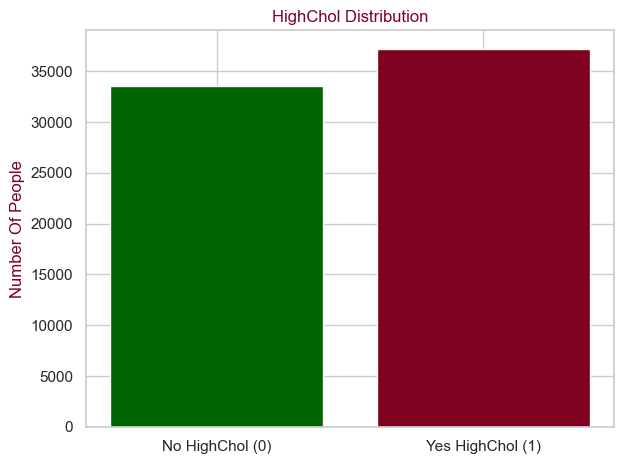

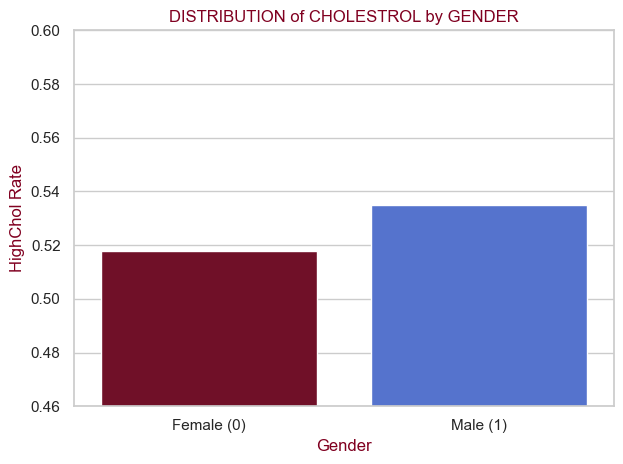

In [4]:
# DISTRIBUTION OF HighChol (Cholesterol)

# Counting HighChol Values
counts = df['HighChol'].value_counts().sort_index()

# Setting Colors of Bars
colors = ['#006400' if val == 0 else '#800020' for val in counts.index]

# Ploting HighChol Distribution
plt.figure()
plt.bar(
    counts.index.astype(str),
    counts.values,
    color=colors
)
plt.xticks(
    [0, 1],
    ['No HighChol (0)', 'Yes HighChol (1)']
)
plt.ylabel('Number Of People', color='#800020')
plt.title('HighChol Distribution', color='#800020')
plt.tight_layout()


# DISTRIBUTION of CHOLESTROL by GENDER

highchol_balance = df.groupby('Sex')['HighChol'].mean().reset_index()
highchol_balance.columns = ['Sex', 'HighChol_Rate']

# Oranları yüzde formatında yazdırmak için
highchol_balance['HighChol_Percent'] = (highchol_balance['HighChol_Rate'] * 100).map('{:.2f}%'.format)

print("\nDISTRIBUTION of CHOLESTROL by GENDER")
print(highchol_balance.to_markdown(index=False))
print("0 = Female, 1 = Male")

custom_palette = {
    0.0: '#800020',
    1.0: '#4169e1'
}

plt.figure()
sns.barplot(
    x='Sex',
    y='HighChol_Rate',
    hue='Sex',
    data=highchol_balance,
    palette=custom_palette,
    dodge=False,
    legend=False
)

# X ekseni etiketleri
plt.xticks([0, 1], ['Female (0)', 'Male (1)'])

# Y ekseni ölçüsü
plt.ylim(0.46, 0.6)

# Başlık ve eksen renkleri
plt.title('DISTRIBUTION of CHOLESTROL by GENDER', color='#800020')
plt.xlabel('Gender', color='#800020')
plt.ylabel('HighChol Rate', color='#800020')
plt.tight_layout()